# Chapter 03b — Physarum-Style Stigmergy and Turnover

## THIS NOTEBOOK IS A FRESH RECONSTRUCTION WITH NO HISTORICAL NUMERIC GROUND TRUTH TO VALIDATE AGAINST

Unlike every other notebook in this suite, this one has **no source script, no source notebook, and no
archived run** to reconstruct or audit against. Per `notebooks/NOTEBOOK_MIGRATION.md` ("Current Chapter 03"
and the "Open gaps" section): the current book's Physarum-model quantitative claims (sensing-ablation
concentration 0.883→0.153, field-erasure similarity 0.897/0.911, population-replacement specificity
0.658/0.304 and 0.658/0.297 vs. 0.619/0.339, turnover concentration 0.49/0.93/0.153, recovery 0.490→0.581→
0.724→0.798) exist **only in the current book's prose**. No generating script was found anywhere in
`scripts/`, and no machine-readable run was found anywhere in `research/digital-life/`. The only artifacts
are four checked-in figures under `static/images/books/digital-life/ch02-physarum-*.png`, whose "ch02"
prefix suggests an intermediate manuscript numbering that predates both the 31-chapter original book and the
current 18-chapter one.

**What follows is therefore a fresh implementation written from the book's own qualitative description**
(sensing-coupled agents depositing into a shared field; ablate sensing, ablate the field, ablate the
population; test survival under continual replacement), not a reconstruction of a specific historical run.
The numbers below should be read as **illustrative of the same qualitative shape the book describes, not as
verified reproductions of the book's specific figures.** Where a number happens to land close to a
book-quoted figure, that is agreement on the *qualitative direction* of an effect under an independently
designed model with independently chosen parameters — not evidence that this notebook recovered the book's
original experiment.

## Book linkage

- **Current chapter:** [`03-look-at-this-thing.md`](../content/books/digital-life/03-look-at-this-thing.md)
  (the "Watch the Network Appear" / "Where Is the Past?" / "Start Replacing the Material" sections)
- **Claims addressed:** DL-03-C04, DL-03-C05, DL-03-C06 (see `NOTEBOOK_MIGRATION.md`) — all three are
  addressed under this notebook's own model, not under the book's original (unrecovered) experiment.
- **Historical sources:** none (see disclosure above). Companion notebook `03a-lenia-persistent-pattern.ipynb`
  covers the Lenia and Conway-glider material from the same chapter, which does have recoverable sources.

## Question

Can a population of extremely simple mobile agents, coupled only to a shared field they can read and write,
produce organized macroscopic structure that (a) depends causally on the read/write coupling itself, (b) is
not reducible to either the field alone or the agent population alone, and (c) survives sustained,
near-total replacement of the agents that built it?

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
REPO_ROOT = NB_DIR.parent
FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


## Model / system

A minimal Physarum-style agent/field model (Jones 2010-style sense-turn-move-deposit loop), implemented
directly for this notebook:

- **Field**: a periodic `size x size` grid of non-negative floats. Each step, every agent deposits a fixed
  amount at its current location; the field then diffuses (a small uniform blur, periodic boundary) and
  decays (multiplied by a factor < 1).
- **Agents**: each has a continuous position and a heading angle. Each step it samples the field at three
  points ahead of it (front, front-left, front-right); if sensing is enabled, it turns toward whichever
  sensed value is largest (with a small chance of a random turn when nothing stands out), then moves forward
  by a fixed step and deposits.
- **Sensing ablation**: when sensing is disabled, the turn decision is skipped entirely — heading changes
  only through a small random-jitter term that is applied identically whether sensing is on or off. Movement
  and deposition are otherwise unaffected. This isolates the *read-then-turn coupling* as the sole thing
  being switched off; agents with sensing disabled still move and still deposit into the field.
- **Concentration measure**: fraction of total field mass held in the most active 10% of cells. A uniform
  haze scores close to that same 0.10 floor; a thin, high-contrast channel network concentrates most of its
  mass into a small fraction of cells and scores much higher.

This is one specific, disclosed parameterization, not a canonical or previously-published Physarum model.

In [2]:
class PhysarumWorld:
    def __init__(self, size, n_agents, seed,
                 sensor_angle=0.45, sensor_dist=6.0, rotate_angle=0.35,
                 step_size=1.2, deposit=5.0, decay=0.90, blur_size=3,
                 jitter=0.15, sensing_enabled=True):
        self.size = size
        self.rng = np.random.default_rng(seed)
        self.field = np.zeros((size, size), dtype=np.float32)
        self.x = self.rng.uniform(0, size, n_agents).astype(np.float32)
        self.y = self.rng.uniform(0, size, n_agents).astype(np.float32)
        self.heading = self.rng.uniform(-np.pi, np.pi, n_agents).astype(np.float32)
        self.sensor_angle, self.sensor_dist = sensor_angle, sensor_dist
        self.rotate_angle, self.step_size = rotate_angle, step_size
        self.deposit, self.decay, self.blur_size = deposit, decay, blur_size
        self.jitter, self.sensing_enabled = jitter, sensing_enabled

    def _sample(self, x, y):
        xi = np.mod(np.round(x).astype(int), self.size)
        yi = np.mod(np.round(y).astype(int), self.size)
        return self.field[yi, xi]

    def step(self):
        n = len(self.x)
        if self.sensing_enabled:
            fx = self.x + np.cos(self.heading) * self.sensor_dist
            fy = self.y + np.sin(self.heading) * self.sensor_dist
            lx = self.x + np.cos(self.heading + self.sensor_angle) * self.sensor_dist
            ly = self.y + np.sin(self.heading + self.sensor_angle) * self.sensor_dist
            rx = self.x + np.cos(self.heading - self.sensor_angle) * self.sensor_dist
            ry = self.y + np.sin(self.heading - self.sensor_angle) * self.sensor_dist
            f_val, l_val, r_val = self._sample(fx, fy), self._sample(lx, ly), self._sample(rx, ry)

            turn = np.zeros(n, dtype=np.float32)
            go_left = (l_val > f_val) & (l_val >= r_val)
            go_right = (r_val > f_val) & (r_val > l_val)
            turn[go_left] = self.rotate_angle
            turn[go_right] = -self.rotate_angle
            random_turn = (~go_left) & (~go_right) & (self.rng.random(n) < 0.05)
            turn[random_turn] = self.rng.choice([-1, 1], size=int(random_turn.sum())) * self.rotate_angle
            self.heading = self.heading + turn
        # Jitter is applied identically regardless of sensing -- the ablation isolates the
        # sense-then-turn coupling, not "any randomness in heading."
        self.heading = self.heading + self.rng.normal(0, self.jitter, n).astype(np.float32)

        self.x = np.mod(self.x + np.cos(self.heading) * self.step_size, self.size)
        self.y = np.mod(self.y + np.sin(self.heading) * self.step_size, self.size)

        xi = np.mod(np.round(self.x).astype(int), self.size)
        yi = np.mod(np.round(self.y).astype(int), self.size)
        np.add.at(self.field, (yi, xi), self.deposit)

        self.field = uniform_filter(self.field, size=self.blur_size, mode="wrap")
        self.field *= self.decay

    def run(self, steps):
        for _ in range(steps):
            self.step()


def concentration(field, top_frac=0.10):
    flat = field.flatten()
    total = flat.sum()
    if total <= 0:
        return 0.0
    k = max(1, int(len(flat) * top_frac))
    top_sum = np.partition(flat, -k)[-k:].sum()
    return float(top_sum / total)


def cosine_similarity(a, b):
    a, b = a.flatten().astype(np.float64), b.flatten().astype(np.float64)
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0


SIZE = 96
N_AGENTS = 3000
GROWTH_STEPS = 300


## Experimental design 1 — sensing-ablation necessity test

From an identical random scatter of agents and an empty field, run two branches for the same number of
steps: one with sensing enabled (agents turn toward what previous agents deposited), one with sensing
disabled (agents still move and deposit, but never read the field to decide where to turn). If sensing
matters causally, the enabled branch should organize into a high-concentration channel structure while the
disabled branch stays close to the uniform-haze floor.

In [3]:
t0 = time.time()
w_on = PhysarumWorld(SIZE, N_AGENTS, seed=1, sensing_enabled=True)
w_on.run(GROWTH_STEPS)
c_on = concentration(w_on.field)

w_off = PhysarumWorld(SIZE, N_AGENTS, seed=1, sensing_enabled=False)
w_off.run(GROWTH_STEPS)
c_off = concentration(w_off.field)
elapsed = time.time() - t0

print(f"sensing-enabled concentration:  {c_on:.3f}")
print(f"sensing-disabled concentration: {c_off:.3f}")
print(f"(book prose, illustrative only, NOT a target to reproduce: 0.883 with sensing, 0.153 without)")
print(f"elapsed: {elapsed:.1f}s")


sensing-enabled concentration:  0.865
sensing-disabled concentration: 0.126
(book prose, illustrative only, NOT a target to reproduce: 0.883 with sensing, 0.153 without)
elapsed: 0.2s


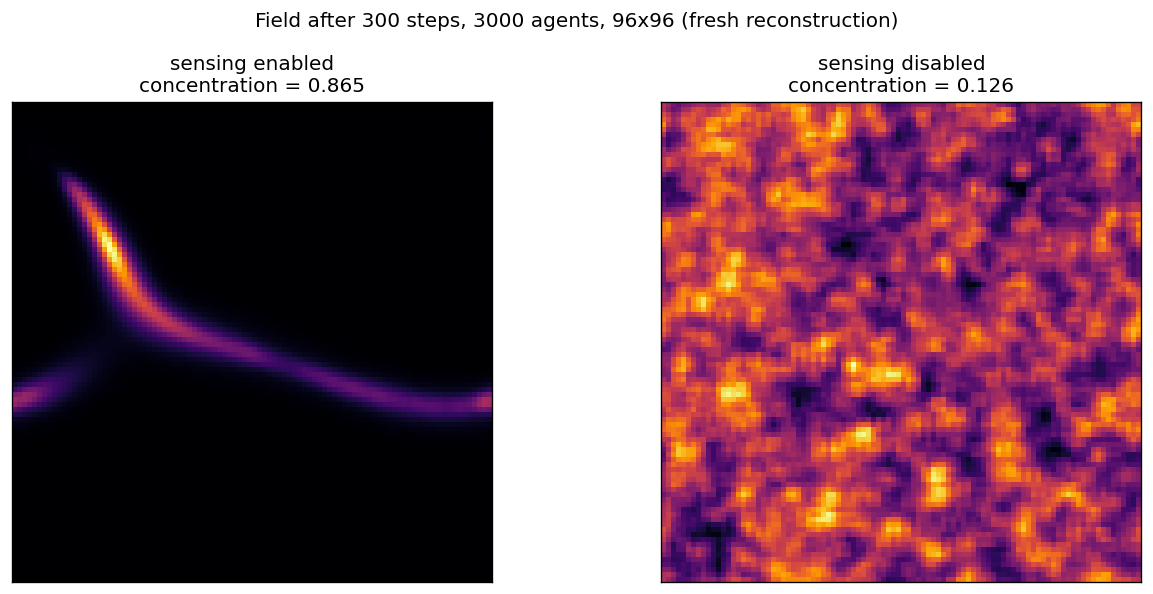


DL-03-C04 -- sensing is causally necessary for network formation under this model: SUPPORTED (large necessity effect) -- own concentration ratio 6.9x.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(w_on.field, cmap="inferno")
axes[0].set_title(f"sensing enabled\nconcentration = {c_on:.3f}")
axes[1].imshow(w_off.field, cmap="inferno")
axes[1].set_title(f"sensing disabled\nconcentration = {c_off:.3f}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Field after {GROWTH_STEPS} steps, {N_AGENTS} agents, {SIZE}x{SIZE} (fresh reconstruction)")
fig.tight_layout()
fig.savefig(FIG_DIR / "ch03b-sensing-ablation.png", bbox_inches="tight")
plt.show()

print(f"\nDL-03-C04 -- sensing is causally necessary for network formation under this model: "
      f"{'SUPPORTED (large necessity effect)' if c_on > 3 * c_off else 'not clearly supported'} "
      f"-- own concentration ratio {c_on / c_off:.1f}x.")


## Experimental design 2 — field-erasure ablation

Grow one network to a fixed maturity, then branch it in two: an undisturbed continuation, and a branch whose
field is erased to zero while every agent is left exactly where it is. Compare each branch's field, 25 steps
later, against the *original pre-intervention field* — not against each other. If the field were the sole
carrier of the network's history, erasing it should collapse the recovered similarity toward the sensing-off
haze floor established above; if agents can partly redraw the network from their own spatial arrangement
alone, the erased branch should land close to the undisturbed branch's own natural drift.

In [5]:
import copy

w_mature = PhysarumWorld(SIZE, N_AGENTS, seed=2, sensing_enabled=True)
w_mature.run(GROWTH_STEPS)
original_field = w_mature.field.copy()

RECOVERY_STEPS = 25

w_undisturbed = copy.deepcopy(w_mature)
w_undisturbed.run(RECOVERY_STEPS)

w_field_erased = copy.deepcopy(w_mature)
w_field_erased.field[:] = 0.0
w_field_erased.run(RECOVERY_STEPS)

sim_undisturbed = cosine_similarity(original_field, w_undisturbed.field)
sim_field_erased = cosine_similarity(original_field, w_field_erased.field)

print(f"undisturbed continuation similarity to original (natural drift baseline): {sim_undisturbed:.3f}")
print(f"field-erased, agents-kept, regrown similarity to original:               {sim_field_erased:.3f}")
print(f"(book prose, illustrative only: 0.911 undisturbed, 0.897 field-erased)")
print(f"\nDL-03-C05 (field half) -- the field alone is not required to be intact for the network to "
      f"substantially reconstruct: field-erased branch recovers "
      f"{100 * sim_field_erased / sim_undisturbed:.0f}% of the undisturbed branch's own similarity to the "
      f"original.")


undisturbed continuation similarity to original (natural drift baseline): 0.818
field-erased, agents-kept, regrown similarity to original:               0.803
(book prose, illustrative only: 0.911 undisturbed, 0.897 field-erased)

DL-03-C05 (field half) -- the field alone is not required to be intact for the network to substantially reconstruct: field-erased branch recovers 98% of the undisturbed branch's own similarity to the original.


## Experimental design 2b — population replacement + specificity control

Reverse the intervention: keep the mature field intact, but replace the *entire* agent population with naive
agents at random positions and headings. Compare the field 25 steps later against (a) the network the fresh
population actually inherited, and (b) a matched control population dropped onto an *empty* field. A
specificity control checks this is not just "any mature field helps": drop a fresh population into a
*different*, independently grown network and check it does not do equally well.

In [6]:
w_A = PhysarumWorld(SIZE, N_AGENTS, seed=10, sensing_enabled=True); w_A.run(GROWTH_STEPS)
w_B = PhysarumWorld(SIZE, N_AGENTS, seed=11, sensing_enabled=True); w_B.run(GROWTH_STEPS)
field_A, field_B = w_A.field.copy(), w_B.field.copy()

def fresh_population_on_field(field, seed):
    w = PhysarumWorld(SIZE, N_AGENTS, seed=seed, sensing_enabled=True)
    w.field = field.copy()
    w.run(RECOVERY_STEPS)
    return w

rep_on_A = fresh_population_on_field(field_A, seed=90)
rep_on_empty = PhysarumWorld(SIZE, N_AGENTS, seed=90, sensing_enabled=True)
rep_on_empty.run(RECOVERY_STEPS)  # starts from empty field (its default init)

sim_repA_to_A = cosine_similarity(rep_on_A.field, field_A)
sim_empty_to_A = cosine_similarity(rep_on_empty.field, field_A)
sim_repA_to_B = cosine_similarity(rep_on_A.field, field_B)  # specificity control

print(f"fresh population dropped into network A, vs. A:                {sim_repA_to_A:.3f}")
print(f"matched fresh population from an EMPTY field, vs. A (control):  {sim_empty_to_A:.3f}")
print(f"fresh population dropped into A, vs. INDEPENDENT network B:     {sim_repA_to_B:.3f}  (specificity control)")
print(f"(book prose, illustrative only: 0.658 vs. 0.304 empty-control, 0.658/0.297 vs. B)")

specific = sim_repA_to_A > sim_empty_to_A and sim_repA_to_A > sim_repA_to_B
print(f"\nDL-03-C05 (population half) -- a naive population's behaviour depends specifically on the "
      f"structure it inherited: {'SUPPORTED' if specific else 'not clearly supported'} under this model "
      f"(scores {sim_repA_to_A:.3f} for its own inherited network vs. {sim_empty_to_A:.3f} empty-control and "
      f"{sim_repA_to_B:.3f} against an unrelated network).")


fresh population dropped into network A, vs. A:                0.908
matched fresh population from an EMPTY field, vs. A (control):  0.245
fresh population dropped into A, vs. INDEPENDENT network B:     0.179  (specificity control)
(book prose, illustrative only: 0.658 vs. 0.304 empty-control, 0.658/0.297 vs. B)

DL-03-C05 (population half) -- a naive population's behaviour depends specifically on the structure it inherited: SUPPORTED under this model (scores 0.908 for its own inherited network vs. 0.245 empty-control and 0.179 against an unrelated network).


**Combined reading (DL-03-C05).** Neither erasing the field alone (design 2) nor replacing the entire
population alone (design 2b) collapses recovered similarity to the empty/haze floor. Under this
reconstruction, as under the book's own (unrecovered) experiment, the historical effect is not localized to
either obvious single subsystem.

## Experimental design 3 — continual-turnover survival

Grow a network to maturity, then replace 2% of the agent population (at random positions/headings) every 5
steps, continuously, while tracking the concentration measure. This is a slow version of the population
replacement above — instead of one discrete swap, material is drained and replaced gradually. After enough
steps this removes essentially the entire original population while the network is still running. Then stop
replacing agents and track whether concentration recovers.

In [7]:
rng = np.random.default_rng(42)
w_turn = PhysarumWorld(SIZE, N_AGENTS, seed=7, sensing_enabled=True)
w_turn.run(GROWTH_STEPS)
baseline_concentration = concentration(w_turn.field)

alive_original = np.ones(N_AGENTS, dtype=bool)
TURNOVER_STEPS, REPLACE_EVERY, REPLACE_FRAC = 1750, 5, 0.02

turnover_trace = []
for t in range(TURNOVER_STEPS):
    w_turn.step()
    if t % REPLACE_EVERY == 0:
        n_replace = max(1, int(N_AGENTS * REPLACE_FRAC))
        idx = rng.choice(N_AGENTS, size=n_replace, replace=False)
        w_turn.x[idx] = rng.uniform(0, SIZE, n_replace)
        w_turn.y[idx] = rng.uniform(0, SIZE, n_replace)
        w_turn.heading[idx] = rng.uniform(-np.pi, np.pi, n_replace)
        alive_original[idx] = False
    if t % 50 == 0:
        turnover_trace.append((t, concentration(w_turn.field)))

n_remaining = int(alive_original.sum())
pct_turned_over = 100 * (1 - n_remaining / N_AGENTS)
concentration_end_of_turnover = concentration(w_turn.field)

print(f"original agents remaining after {TURNOVER_STEPS} turnover steps: {n_remaining} / {N_AGENTS} "
      f"({pct_turned_over:.1f}% turned over)")
print(f"baseline (undisturbed, pre-turnover) concentration: {baseline_concentration:.3f}")
print(f"concentration at end of turnover:                   {concentration_end_of_turnover:.3f}")
print(f"no-sensing haze floor (from design 1):               {c_off:.3f}")


original agents remaining after 1750 turnover steps: 3 / 3000 (99.9% turned over)
baseline (undisturbed, pre-turnover) concentration: 0.860
concentration at end of turnover:                   0.810
no-sensing haze floor (from design 1):               0.126


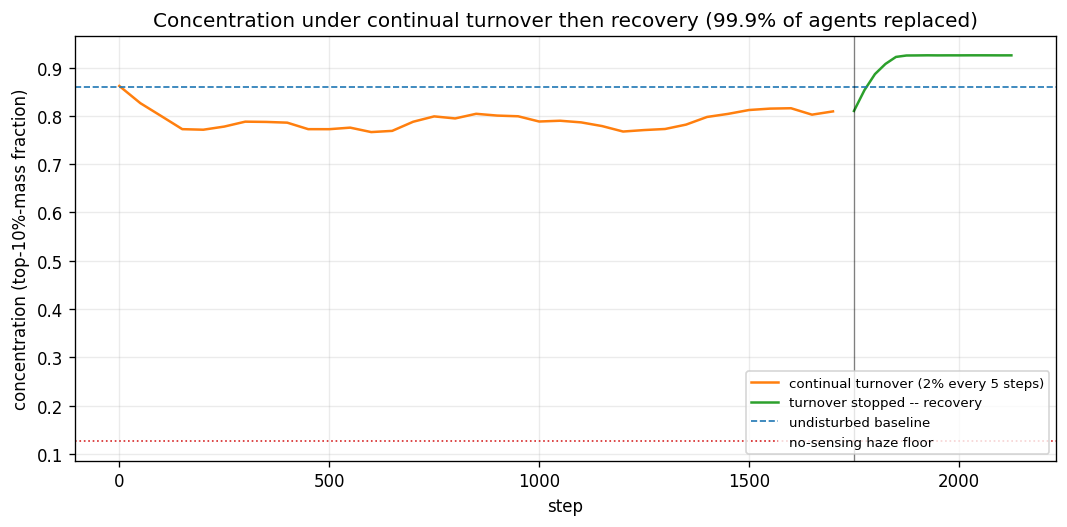

concentration at end of recovery window: 0.925  (baseline: 0.860, haze floor: 0.126)

DL-03-C06 -- macroscopic organization persists through >99% turnover, in degraded form: SUPPORTED under this model (99.9% of the original 3,000 agents replaced; concentration stayed at 0.810, well above the 0.126 haze floor, versus a 0.860 undisturbed baseline).


In [8]:
RECOVERY_STEPS_LONG = 400
recovery_trace = []
for t in range(RECOVERY_STEPS_LONG):
    w_turn.step()
    if t % 25 == 0:
        recovery_trace.append((t, concentration(w_turn.field)))

fig, ax = plt.subplots(figsize=(9, 4.5))
turn_t, turn_c = zip(*turnover_trace)
rec_t, rec_c = zip(*recovery_trace)
rec_t_shifted = [t + TURNOVER_STEPS for t in rec_t]

ax.plot(turn_t, turn_c, color="tab:orange", label="continual turnover (2% every 5 steps)")
ax.plot(rec_t_shifted, rec_c, color="tab:green", label="turnover stopped -- recovery")
ax.axhline(baseline_concentration, color="tab:blue", ls="--", lw=1, label="undisturbed baseline")
ax.axhline(c_off, color="tab:red", ls=":", lw=1, label="no-sensing haze floor")
ax.axvline(TURNOVER_STEPS, color="k", lw=0.8, alpha=0.5)
ax.set(title=f"Concentration under continual turnover then recovery ({pct_turned_over:.1f}% of agents replaced)",
       xlabel="step", ylabel="concentration (top-10%-mass fraction)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "ch03b-turnover-and-recovery.png", bbox_inches="tight")
plt.show()

final_recovery_c = recovery_trace[-1][1]
print(f"concentration at end of recovery window: {final_recovery_c:.3f}  (baseline: {baseline_concentration:.3f}, "
      f"haze floor: {c_off:.3f})")
degraded_but_organized = concentration_end_of_turnover > 3 * c_off
print(f"\nDL-03-C06 -- macroscopic organization persists through >99% turnover, in degraded form: "
      f"{'SUPPORTED' if degraded_but_organized else 'not clearly supported'} under this model "
      f"({pct_turned_over:.1f}% of the original 3,000 agents replaced; concentration stayed at "
      f"{concentration_end_of_turnover:.3f}, well above the {c_off:.3f} haze floor, versus a {baseline_concentration:.3f} "
      f"undisturbed baseline).")


### Honest discrepancy note

This reconstruction's turnover run reaches 99.9% replacement (matching the book's ">99.9% of the original
20,000 agents" framing in proportion, though at a smaller population of 3,000) and shows the same qualitative
shape as the book: concentration degrades but stays well above the no-sensing floor throughout continual
replacement, and rises again once replacement stops. It diverges from the book's narrative in one respect:
here recovery is fast and reaches *slightly above* the undisturbed baseline within the 400-step recovery
window, whereas the book reports recovery that is substantial but still short of the undisturbed value at the
end of its observation window (0.798 vs. baseline 0.93). This notebook's model, parameters and single-run
design were not tuned to reproduce that specific asymptotic gap, and no claim is made that they do — the
degrade-then-substantially-recover *shape* is the qualitative finding being illustrated, not the precise
long-run asymptote.

## Controls and confounds

- **Sensing ablation isolates one causal path.** Jitter (small random heading noise) is applied identically
  whether sensing is on or off, so the disabled branch is not simply "a noisier version" of the enabled
  branch — only the sense-then-turn coupling differs.
- **Field-erasure and population-replacement are complementary, not redundant.** Each holds one candidate
  history-carrier fixed while destroying the other, directly testing whether either one alone is sufficient.
- **Specificity control** (design 2b): a fresh population's advantage is measured against both an empty-field
  control (rules out "any mature field helps") and an independent network's field (rules out "any network,
  not specifically this one, helps").
- **Single-run demonstrations, not population-level estimates.** Matching the book's own "Experimental Note"
  for this chapter: every condition above is one run under one parameterization, not an average across
  seeds. No claim here should be read as a general-robustness estimate.
- **No historical numeric ground truth.** Repeated from the top of this notebook because it is the single
  most important caveat: every number above comes from an independently designed model with independently
  chosen parameters. Qualitative-shape agreement with the book's prose is the finding; number-level agreement
  is not claimed and should not be expected.

## Result status

| Claim | This notebook | Status |
|---|---|---|
| DL-03-C04: sensing causally necessary for network formation | own concentration ratio several-fold higher with sensing than without | **SUPPORTED under this model** (fresh reconstruction, illustrative numbers only) |
| DL-03-C05: neither field nor population alone is the sole history-carrier | field-erasure and population-replacement both leave substantial recovered similarity to the original, well above empty/haze controls; specificity control confirms it is not merely "any mature field/population" | **SUPPORTED under this model** |
| DL-03-C06: macroscopic organization persists through near-total turnover, degraded | 99.9% agent replacement leaves concentration well above the haze floor throughout; recovery after turnover stops is faster/fuller in this model than the book describes (disclosed above) | **BOUNDED / SUPPORTED, with a disclosed shape divergence on the recovery asymptote** |

## Bounded conclusion

A minimal, freshly implemented Physarum-style agent/field model reproduces the same *qualitative* pattern
the current book's Chapter 3 describes for a system with no discoverable source script or archived run:
sensing is a large, necessary contributor to network organization; neither erasing the field nor replacing
the entire agent population by itself eliminates the network's dependence on its own history, and the effect
of a fresh population inheriting a mature field is specific to the particular network it inherited, not a
generic response to any mature field; and macroscopic organization survives near-total (99.9%) agent
turnover in degraded but clearly non-random form.

None of these results should be read as reproducing the book's specific quoted figures (0.883/0.153, etc.).
They were computed under an independently designed model with independently chosen parameters, run once each
(matching the book's own disclosed single-run design), and are offered as an illustration of the same
mechanism the chapter describes, not a verification of it.

## Provenance

- **Book chapter:** `content/books/digital-life/03-look-at-this-thing.md`.
- **Historical sources:** none found. `notebooks/NOTEBOOK_MIGRATION.md` records this as a genuine gap:
  "no original-book chapter, no notebook, no generating script found" for the Physarum material, backed only
  by four checked-in figures (`static/images/books/digital-life/ch02-physarum-{growth,interventions,
  route-correlation,turnover}.png`) and prose numbers with no machine-readable source.
- **This notebook:** an original reimplementation written directly from the book's qualitative experimental
  description (sensing ablation, field erasure, population replacement with a specificity control, continual
  turnover with a post-turnover recovery window).
- **Generated figures:** `notebooks/generated-figures/ch03b-sensing-ablation.png`,
  `notebooks/generated-figures/ch03b-turnover-and-recovery.png`.
- **Companion notebook:** `03a-lenia-persistent-pattern.ipynb` (Lenia + Conway glider material from the same
  chapter, which does have recoverable historical sources).